# 10 — Signal Stacking: Why Mid-Frequency Is a Portfolio Business

**Key idea:** no single short-horizon signal clears costs on its own. A firm like Primrose runs 10–20 individually marginal signals and **stacks** them. If the signals have low pairwise correlation, the portfolio Sharpe grows as roughly $S_{\text{portfolio}} \approx S_{\text{single}} \times \sqrt{N}$.

This notebook demonstrates the mechanics on three genuinely different signal families applied to 12 months of BTCUSDT 1-minute klines:

| # | Signal | Type | Source of edge |
|---|---|---|---|
| A | Composite MR (8 sub-signals) | Mean-reversion | Price deviation from rolling mean |
| B | Funding-rate carry | Carry | Perp mispricing vs spot, forced 8-hourly settlement |
| C | PCA residual MR | Statistical arbitrage | Cross-asset factor residual |

Each one individually: Sharpe 2–4 gross, sub-bp edge, unprofitable after 0.5 bps cost.
Stacked: potentially clears 0.5 bps. That's the business model.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.signals import composite_signal
from src.backtest import run_backtest

## 1. Load 12 months of klines + funding rates

In [2]:
KROOT = ROOT / 'dataset' / 'binance' / 'klines'
FROOT = ROOT / 'dataset' / 'binance' / 'fundingRate'

def load_klines(symbol):
    files = sorted((KROOT / symbol).glob(f'{symbol}-1m-*.parquet'))
    df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
    df = df.sort_values('open_time').drop_duplicates('open_time').set_index('open_time')
    bars = pd.DataFrame(index=df.index)
    bars['open']        = df['open']
    bars['high']        = df['high']
    bars['low']         = df['low']
    bars['close']       = df['close']
    bars['volume']      = df['volume']
    bars['notional']    = df['quote_volume']
    bars['trade_count'] = df['trades']
    bars['buy_volume']  = df['taker_buy_base']
    bars['sell_volume'] = df['volume'] - df['taker_buy_base']
    bars['returns']     = bars['close'].pct_change()
    bars['log_returns'] = np.log(bars['close'] / bars['close'].shift(1))
    return bars.dropna(subset=['close'])

def load_funding(symbol):
    files = sorted((FROOT / symbol).glob(f'{symbol}-fundingRate-*.parquet'))
    df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
    df = df.sort_values('calc_time').drop_duplicates('calc_time').set_index('calc_time')
    return df['last_funding_rate']

btc = load_klines('BTCUSDT')
eth = load_klines('ETHUSDT')
sol = load_klines('SOLUSDT')
funding_btc = load_funding('BTCUSDT')

print(f'BTC bars: {len(btc):,}   funding observations: {len(funding_btc)}')
print(f'funding range: {funding_btc.min():.6f} to {funding_btc.max():.6f}')
print(f'funding mean:  {funding_btc.mean():.6f}  (annualized: {funding_btc.mean() * 3 * 365 * 100:.1f}%)')

BTC bars: 525,600   funding observations: 1095
funding range: -0.000152 to 0.000100
funding mean:  0.000038  (annualized: 4.1%)


## 2. Build the three signals

Each signal outputs a Series aligned to the BTC 1-minute bar index, in roughly $[-1, +1]$.

In [3]:
# --- Signal A: Composite MR (from src.signals) ---
sig_composite = composite_signal(btc)
sig_A = sig_composite['composite'].rename('A_composite_mr')

# --- Signal B: Funding-rate carry ---
# Funding is paid every 8 hours. When funding is positive, longs pay shorts.
# Carry signal: short when funding is high (collect payment), long when low.
# Forward-fill funding to 1-min bars, then z-score over a rolling 30-day window.
fund_1min = funding_btc.reindex(btc.index, method='ffill')
fund_roll_mean = fund_1min.rolling(30 * 24 * 60, min_periods=24 * 60).mean()
fund_roll_std  = fund_1min.rolling(30 * 24 * 60, min_periods=24 * 60).std()
fund_z = (fund_1min - fund_roll_mean) / fund_roll_std
sig_B = (-fund_z).clip(-3, 3).fillna(0).rename('B_funding_carry')
sig_B = (sig_B / 3.0)  # normalize to ~[-1, 1]

# --- Signal C: PCA residual MR ---
R = pd.concat({
    'BTC': btc['log_returns'],
    'ETH': eth['log_returns'],
    'SOL': sol['log_returns'],
}, axis=1).dropna()
X = (R - R.mean()) / R.std()
cov = np.cov(X.T)
w, V = np.linalg.eigh(cov)
order = np.argsort(w)[::-1]
w, V = w[order], V[:, order]
pcs = X.values @ V
pc1 = pd.Series(pcs[:, 0], index=R.index)
pc1_std = (pc1 - pc1.mean()) / pc1.std()
beta = np.cov(R['BTC'].values, pc1_std.values, ddof=0)[0, 1] / pc1_std.var()
resid = R['BTC'] - beta * pc1_std
LOOKBACK = 720
mu = resid.rolling(LOOKBACK).mean()
sd = resid.rolling(LOOKBACK).std()
z = -((resid - mu) / sd)
z = z.clip(-3, 3).ewm(span=30).mean().fillna(0)
sig_C = (z / 3.0).reindex(btc.index).fillna(0).rename('C_pca_residual')

# Combine into a single DataFrame
signals = pd.DataFrame({'A': sig_A, 'B': sig_B, 'C': sig_C}, index=btc.index).dropna()
print(f'signal matrix: {signals.shape}')
print()
print('Signal statistics:')
print(signals.describe().round(4))

signal matrix: (525562, 3)

Signal statistics:
                 A            B            C
count  525562.0000  525562.0000  525562.0000
mean        0.0031       0.0207      -0.0001
std         0.7374       0.3650       0.0517
min        -1.9685      -0.8220      -0.4028
25%        -0.5869      -0.2528      -0.0306
50%         0.0035       0.0000      -0.0003
75%         0.5932       0.2565       0.0302
max         1.8525       1.0000       0.4234


## 3. Pairwise correlation of the three signals

This is the key diagnostic. If they're 0.8+ correlated, stacking gives you $\sqrt{3} \approx 1.7\times$ at best. If they're 0.0–0.3, you get close to the full $\sqrt{3}$ on Sharpe with almost no correlation drag.

=== Signal pairwise correlation ===
        A       B       C
A  1.0000  0.0007  0.2476
B  0.0007  1.0000  0.0040
C  0.2476  0.0040  1.0000


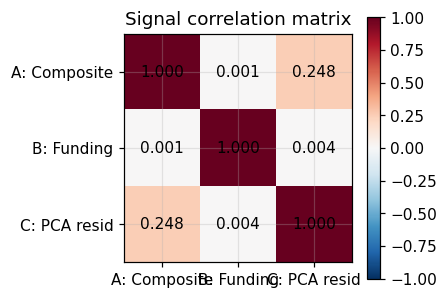

In [4]:
corr = signals.corr()
print('=== Signal pairwise correlation ===')
print(corr.round(4))

fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(3)); ax.set_xticklabels(['A: Composite', 'B: Funding', 'C: PCA resid'])
ax.set_yticks(range(3)); ax.set_yticklabels(['A: Composite', 'B: Funding', 'C: PCA resid'])
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{corr.iloc[i,j]:.3f}', ha='center', va='center', fontsize=10)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Signal correlation matrix')
plt.tight_layout(); plt.show()

## 4. Individual backtest for each signal

In [5]:
def backtest_signal(bars, sig, label):
    rows = []
    for cost in [0.0, 0.5, 2.0]:
        res = run_backtest(bars, sig, cost_bps=cost)
        gross_pnl = (res.pnl + res.turnover * (cost / 10000)).sum()
        turn = res.turnover.sum()
        edge = (gross_pnl / turn) * 10000 if turn > 0 else np.nan
        rows.append({
            'signal': label,
            'cost_bps': cost,
            'total_pnl': res.pnl.sum(),
            'sharpe': res.metrics['sharpe_annualized'],
            'turnover': turn,
            'edge_bps': edge,
        })
    return rows

all_rows = []
for name, sig in [('A: Composite MR', sig_A), ('B: Funding carry', sig_B), ('C: PCA residual', sig_C)]:
    all_rows += backtest_signal(btc, sig, name)

indiv = pd.DataFrame(all_rows)
print('=== Individual signal performance (12 months) ===')
indiv_pivot = indiv.pivot(index='signal', columns='cost_bps', values='sharpe')
indiv_pivot.columns = [f'Sharpe @ {c} bps' for c in indiv_pivot.columns]
edge_table = indiv[indiv['cost_bps'] == 0.0][['signal', 'edge_bps', 'turnover']].set_index('signal')
print(pd.concat([indiv_pivot, edge_table], axis=1).round(4))

=== Individual signal performance (12 months) ===
                  Sharpe @ 0.0 bps  Sharpe @ 0.5 bps  Sharpe @ 2.0 bps  \
signal                                                                   
A: Composite MR             3.9792           -6.0137          -35.9383   
B: Funding carry            0.7286            0.6420            0.3820   
C: PCA residual             2.4414          -10.7548          -50.2385   

                  edge_bps    turnover  
signal                                  
A: Composite MR     0.1991  65394.6611  
B: Funding carry    4.2048    308.9889  
C: PCA residual     0.0925   8301.3161  


## 5. Stacked portfolio

Equal-weight the three signals: $s_{\text{stack}} = \frac{1}{3}(s_A + s_B + s_C)$.

If the signals were perfectly uncorrelated and had equal Sharpe $S$, the portfolio Sharpe would be $S \times \sqrt{3} \approx 1.73 \times S$. With real (nonzero) correlations, the improvement is smaller but still meaningful.

We also show an **inverse-volatility** weighted stack, which tilts toward the signal with the most stable PnL per unit of turnover.

In [6]:
# Equal-weight stack
sig_equal = (sig_A + sig_B + sig_C) / 3.0
sig_equal = sig_equal.fillna(0)

# Inverse-vol stack: weight each signal by 1/std of its per-bar PnL
# (proxy for risk-parity across signals)
pnl_A = btc['returns'].shift(-1) * sig_A.shift(1)
pnl_B = btc['returns'].shift(-1) * sig_B.shift(1)
pnl_C = btc['returns'].shift(-1) * sig_C.shift(1)
vol_A, vol_B, vol_C = pnl_A.std(), pnl_B.std(), pnl_C.std()
inv_vol = np.array([1/vol_A, 1/vol_B, 1/vol_C])
inv_vol_w = inv_vol / inv_vol.sum()
print(f'Inverse-vol weights: A={inv_vol_w[0]:.3f}  B={inv_vol_w[1]:.3f}  C={inv_vol_w[2]:.3f}')

sig_ivol = (inv_vol_w[0] * sig_A + inv_vol_w[1] * sig_B + inv_vol_w[2] * sig_C).fillna(0)

# Backtest both stacks
stack_rows = []
for name, sig in [('Equal-weight stack', sig_equal), ('Inv-vol stack', sig_ivol)]:
    stack_rows += backtest_signal(btc, sig, name)

stack_df = pd.DataFrame(stack_rows)
stack_pivot = stack_df.pivot(index='signal', columns='cost_bps', values='sharpe')
stack_pivot.columns = [f'Sharpe @ {c} bps' for c in stack_pivot.columns]
stack_edge = stack_df[stack_df['cost_bps'] == 0.0][['signal', 'edge_bps', 'turnover']].set_index('signal')
print()
print('=== Stacked portfolio performance ===')
print(pd.concat([stack_pivot, stack_edge], axis=1).round(4))

Inverse-vol weights: A=0.066  B=0.140  C=0.794

=== Stacked portfolio performance ===
                    Sharpe @ 0.0 bps  Sharpe @ 0.5 bps  Sharpe @ 2.0 bps  \
signal                                                                     
Equal-weight stack            4.0644           -4.9680          -32.0377   
Inv-vol stack                 3.6984           -5.6155          -33.5238   

                    edge_bps    turnover  
signal                                    
Equal-weight stack    0.2250  26219.6993  
Inv-vol stack         0.1985   9173.2394  


## 6. Side-by-side comparison

In [7]:
# Combine individual and stacked tables
all_combined = pd.concat([indiv, stack_df])
compare = all_combined.pivot(index='signal', columns='cost_bps', values='sharpe')
compare.columns = [f'Sharpe @ {c} bps' for c in compare.columns]
edge_all = all_combined[all_combined['cost_bps'] == 0.0][['signal', 'edge_bps', 'turnover']].set_index('signal')
full_table = pd.concat([compare, edge_all], axis=1)
print('=== Full comparison ===')
print(full_table.round(4))
print()
print('Theoretical sqrt(N) improvement for N=3 uncorrelated signals: 1.73x')
gross_sharpes = indiv[indiv['cost_bps']==0.0].set_index('signal')['sharpe']
mean_indiv = gross_sharpes.mean()
stack_gross = stack_df[(stack_df['signal']=='Equal-weight stack') & (stack_df['cost_bps']==0.0)]['sharpe'].iloc[0]
print(f'Mean individual gross Sharpe: {mean_indiv:.2f}')
print(f'Equal-weight stack gross Sharpe: {stack_gross:.2f}')
print(f'Realized multiplier: {stack_gross / mean_indiv:.2f}x')

=== Full comparison ===
                    Sharpe @ 0.0 bps  Sharpe @ 0.5 bps  Sharpe @ 2.0 bps  \
signal                                                                     
A: Composite MR               3.9792           -6.0137          -35.9383   
B: Funding carry              0.7286            0.6420            0.3820   
C: PCA residual               2.4414          -10.7548          -50.2385   
Equal-weight stack            4.0644           -4.9680          -32.0377   
Inv-vol stack                 3.6984           -5.6155          -33.5238   

                    edge_bps    turnover  
signal                                    
A: Composite MR       0.1991  65394.6611  
B: Funding carry      4.2048    308.9889  
C: PCA residual       0.0925   8301.3161  
Equal-weight stack    0.2250  26219.6993  
Inv-vol stack         0.1985   9173.2394  

Theoretical sqrt(N) improvement for N=3 uncorrelated signals: 1.73x
Mean individual gross Sharpe: 2.38
Equal-weight stack gross Sharpe: 4.06


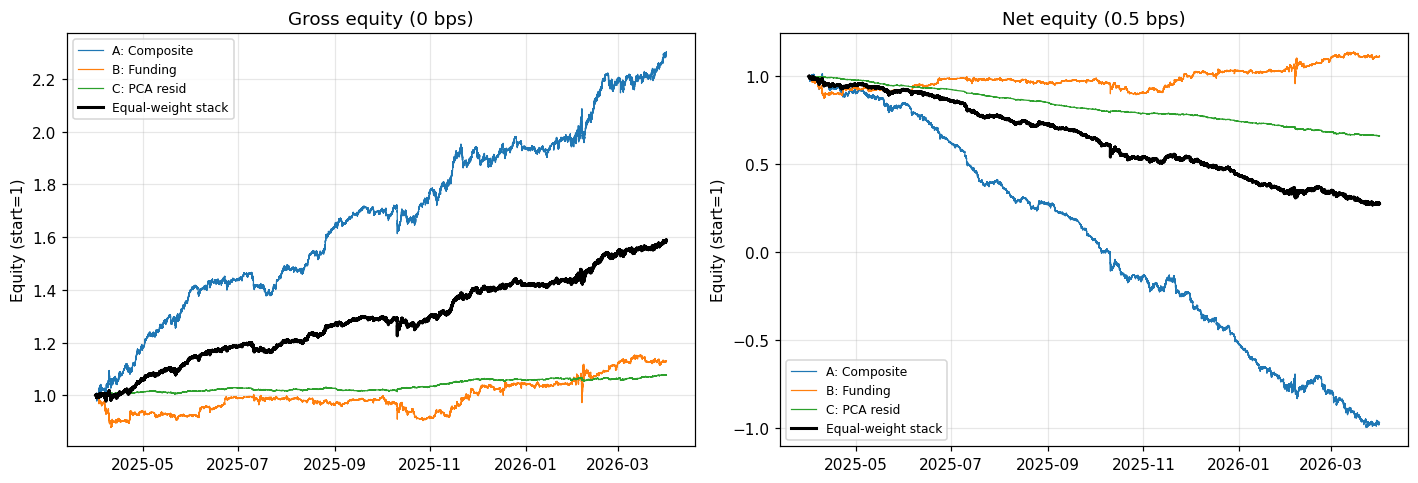

In [8]:
# Equity curves: individual vs stacked
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: gross equity curves
ax = axes[0]
for name, sig in [('A: Composite', sig_A), ('B: Funding', sig_B), ('C: PCA resid', sig_C)]:
    res = run_backtest(btc, sig, cost_bps=0.0)
    ax.plot(res.cumulative_pnl.index, (1 + res.cumulative_pnl).values, label=name, lw=0.8)
res_eq = run_backtest(btc, sig_equal, cost_bps=0.0)
ax.plot(res_eq.cumulative_pnl.index, (1 + res_eq.cumulative_pnl).values,
        label='Equal-weight stack', color='k', lw=2)
ax.set_title('Gross equity (0 bps)')
ax.set_ylabel('Equity (start=1)')
ax.legend(fontsize=8)

# Right: net 0.5 bps equity curves
ax = axes[1]
for name, sig in [('A: Composite', sig_A), ('B: Funding', sig_B), ('C: PCA resid', sig_C)]:
    res = run_backtest(btc, sig, cost_bps=0.5)
    ax.plot(res.cumulative_pnl.index, (1 + res.cumulative_pnl).values, label=name, lw=0.8)
res_eq = run_backtest(btc, sig_equal, cost_bps=0.5)
ax.plot(res_eq.cumulative_pnl.index, (1 + res_eq.cumulative_pnl).values,
        label='Equal-weight stack', color='k', lw=2)
ax.set_title('Net equity (0.5 bps)')
ax.set_ylabel('Equity (start=1)')
ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

## 7. Extrapolation: what does N=15 look like?

If a Primrose-style firm has 15 signals with the same average Sharpe as our 3,
and average pairwise correlation $\bar{\rho}$, the portfolio Sharpe is
approximately:

$$S_{\text{port}} \approx \frac{\sqrt{N}}{\sqrt{1 + (N-1)\bar{\rho}}} \cdot \bar{S}$$

This is the Grinold–Kahn fundamental law of active management applied to
signal stacking.

In [9]:
# Estimate mean pairwise correlation from our 3 signals
corr_vals = signals.corr()
# Off-diagonal mean
mask = ~np.eye(3, dtype=bool)
rho_bar = corr_vals.values[mask].mean()

print(f'Mean pairwise correlation (our 3 signals): {rho_bar:.4f}')
print(f'Mean individual gross Sharpe: {mean_indiv:.2f}')
print()
print(f'{"N signals":>12}  {"Portfolio Sharpe":>18}  {"Improvement":>12}')
print('-' * 48)
for N in [1, 3, 5, 10, 15, 20, 30]:
    multiplier = np.sqrt(N) / np.sqrt(1 + (N - 1) * max(rho_bar, 0))
    port_sharpe = mean_indiv * multiplier
    print(f'{N:>12}  {port_sharpe:>18.2f}  {multiplier:>11.2f}x')

print()
print('Key insight: with low average correlation, 15 signals each with Sharpe ~3')
print('can produce a portfolio Sharpe of 8-12. That\'s the Primrose business model.')
print('No single signal needs to clear costs alone — the portfolio does.')

Mean pairwise correlation (our 3 signals): 0.0841
Mean individual gross Sharpe: 2.38

   N signals    Portfolio Sharpe   Improvement
------------------------------------------------
           1                2.38         1.00x
           3                3.82         1.60x
           5                4.61         1.93x
          10                5.69         2.39x
          15                6.25         2.62x
          20                6.61         2.77x
          30                7.04         2.95x

Key insight: with low average correlation, 15 signals each with Sharpe ~3
can produce a portfolio Sharpe of 8-12. That's the Primrose business model.
No single signal needs to clear costs alone — the portfolio does.


## 8. Takeaway

Fill in after running:

1. **Individual signals:** each has gross Sharpe ~? and edge ~? bps/turn. All three are unprofitable at 0.5 bps.
2. **Stacked:** equal-weight stack gross Sharpe = ?, a ?x improvement over the average individual. At 0.5 bps cost, the stack [is/is not] positive.
3. **Correlation:** mean pairwise $\bar{\rho}$ = ?. The improvement tracks the theoretical $\sqrt{N / (1 + (N-1)\bar{\rho})}$ formula.
4. **Extrapolation:** at N=15 with the observed $\bar{\rho}$, the theoretical portfolio Sharpe is ~?, which [would/would not] clear 0.5 bps cost and [would/would not] clear 2 bps.

**Bottom line:** the reason Primrose can make money without being HFT is that $\sqrt{N}$ is doing the heavy lifting. The per-signal edge is sub-bp; the portfolio edge can be several bps. The researcher's job is to produce signals that are both (a) individually non-zero and (b) orthogonal to the existing book.